# Filtro de Kalman: Temperatura de um Líquido

Este notebook demonstra a aplicação do **filtro de Kalman escalar com ruído de processo**
para estimar a temperatura real de um líquido a partir de medições ruidosas de um sensor.

## Contexto do problema

- Um sensor mede a temperatura de um líquido em **10 instantes**.
- A temperatura verdadeira é **quase constante** (~50 °C), mas flutua levemente.
- As medições possuem **ruído** com variância conhecida.
- O filtro de Kalman estima a temperatura real, suavizando as medições.

Diferente do exemplo do prédio, aqui o **ruído de processo** $Q$ é diferente de zero,
pois a temperatura pode variar levemente entre medições.

## Modelo do Filtro de Kalman Escalar

### Modelo de processo e medição

$$x_k = x_{k-1} + w_k, \quad w_k \sim \mathcal{N}(0, Q)$$

$$z_k = x_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

### Equações do filtro

**Predição:**

$$\hat{x}_{k|k-1} = \hat{x}_{k-1|k-1}$$

$$P_{k|k-1} = P_{k-1|k-1} + Q$$

**Correção:**

$$K_k = \frac{P_{k|k-1}}{P_{k|k-1} + R}$$

$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k \cdot (z_k - \hat{x}_{k|k-1})$$

$$P_{k|k} = (1 - K_k) \cdot P_{k|k-1}$$

### Diferença em relação ao caso anterior (prédio)

No exemplo do prédio, $Q = 0$ porque a altura não muda. Aqui, $Q > 0$ porque a
temperatura pode fluctuar, o que impede que o ganho de Kalman $K$ decresça até zero.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos dados

O CSV contém a temperatura verdadeira (para referência) e a medição ruidosa do sensor.

In [2]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemplo7e8_liquido_aquecido.csv"

df = pd.read_csv(CAMINHO)
df

,n,temp_verdadeira_C,medicao_C
0,1,50.505,50.486
1,2,50.994,50.963
2,3,51.493,51.597
3,4,52.001,52.001
4,5,52.506,52.518
5,6,52.998,53.050
6,7,53.521,53.438
7,8,54.005,53.858
8,9,54.500,54.465
9,10,54.997,55.114


## 3. Parâmetros do filtro

| Parâmetro | Valor | Significado |
|-----------|-------|-------------|
| $x_0$ | 60.0 °C | Estimativa inicial (deliberadamente distante de 50 °C) |
| $P_0$ | 10 000 °C² | Variância inicial muito alta ($\sigma_0 = 100$ °C) |
| $R$ | 0.01 °C² | Variância do ruído de medição ($\sigma_R = 0.1$ °C) |
| $Q$ | 0.0001 °C² | Variância do ruído do processo (flutuação da temperatura) |

> **Nota:** $x_0 = 60$ °C é intencionalmente distante dos ~50 °C reais para mostrar
> como o filtro converge rapidamente mesmo com inicialização incorreta.

In [3]:
# Estado inicial
x = 10.0  # estimativa inicial da temperatura (°C) — propositalmente incorreta
p = 10_000.0  # variância do erro (°C²) — alta incerteza inicial
r = 0.01  # variância do ruído de medição (°C²)
q = 0.15  # variância do ruído do processo (°C²)

# Para o primeiro passo, predição = estado atual
x_pred = x
p_pred = p + q

## 4. Execução do filtro

Para cada medição $z_k$:
1. Calcula o **ganho de Kalman** $K$
2. **Corrige** o estado e a covariância
3. Projeta para o próximo passo (predição)

In [4]:
ganhos = []
estimativas = []
variancias = []

for z in df["medicao_C"]:
    # Ganho de Kalman: peso relativo entre medição e estimativa
    K = p_pred / (p_pred + r)

    # Correção do estado
    x = x_pred + K * (z - x_pred)

    # Correção da covariância
    p = (1 - K) * p_pred

    ganhos.append(K)
    estimativas.append(x)
    variancias.append(p)

    # Predição para o próximo passo (com ruído de processo)
    x_pred = x
    p_pred = p + q  # Q > 0: permite que K não decaia a zero

ganhos = np.array(ganhos)
estimativas = np.array(estimativas)
variancias = np.array(variancias)
medicoes = df["medicao_C"].to_numpy()
verdadeiras = df["temp_verdadeira_C"].to_numpy()
n_passos = np.arange(1, len(medicoes) + 1)

print(
    f"{'Passo':>5} | {'Medido (°C)':>10} | {'Estimado (°C)':>12} | {'Erro (°C)':>8} | {'Ganho K':>8}"
)
print("-" * 58)
for i in range(len(medicoes)):
    erro = medicoes[i] - estimativas[i]
    print(
        f"{n_passos[i]:5d} | {medicoes[i]:10.3f} | {estimativas[i]:12.4f} | {erro:8.4f} | {ganhos[i]:8.4f}"
    )

Passo | Medido (°C) | Estimado (°C) | Erro (°C) |  Ganho K
----------------------------------------------------------
    1 |     50.486 |      50.4860 |   0.0000 |   1.0000
    2 |     50.963 |      50.9349 |   0.0281 |   0.9412
    3 |     51.597 |      51.5579 |   0.0391 |   0.9410
    4 |     52.001 |      51.9748 |   0.0262 |   0.9410
    5 |     52.518 |      52.4859 |   0.0321 |   0.9410
    6 |     53.050 |      53.0167 |   0.0333 |   0.9410
    7 |     53.438 |      53.4131 |   0.0249 |   0.9410
    8 |     53.858 |      53.8317 |   0.0263 |   0.9410
    9 |     54.465 |      54.4276 |   0.0374 |   0.9410
   10 |     55.114 |      55.0735 |   0.0405 |   0.9410


## 5. Métricas de desempenho

In [5]:
erros_vs_medido = medicoes - estimativas
erros_vs_verdade = verdadeiras - estimativas

rmse_filtro = np.sqrt(np.mean(erros_vs_medido**2))
rmse_vs_real = np.sqrt(np.mean(erros_vs_verdade**2))
mae = np.mean(np.abs(erros_vs_medido))
erro_max = np.max(np.abs(erros_vs_medido))
bias = np.mean(erros_vs_medido)

# Métricas das medições brutas (sem filtro) para comparação
rmse_bruto = np.sqrt(np.mean((verdadeiras - medicoes)**2))

print("--- Filtro de Kalman ---")
print(f"RMSE (estimado vs medido):   {rmse_filtro:.4f} °C")
print(f"RMSE (estimado vs verdade):  {rmse_vs_real:.4f} °C")
print(f"Erro absoluto médio:          {mae:.4f} °C")
print(f"Erro máximo:                  {erro_max:.4f} °C")
print(f"Viés (bias):                  {bias:.4f} °C")
print(f"--- Medições brutas (sem filtro) ---")
print(f"RMSE (bruto vs verdade):     {rmse_bruto:.4f} °C")
print(f"Ganho K final:               {ganhos[-1]:.4f}")
print(f"Variância final:             {variancias[-1]:.4f} °C²")
print(f"Incerteza final:             {np.sqrt(variancias[-1]):.4f} °C")
print(f"Redução de RMSE:            "
      f"{(1 - rmse_filtro/ rmse_bruto)*100:.1f}%")

--- Filtro de Kalman ---
RMSE (estimado vs medido):   0.0308 °C
RMSE (estimado vs verdade):  0.0789 °C
Erro absoluto médio:          0.0288 °C
Erro máximo:                  0.0405 °C
Viés (bias):                  0.0288 °C
--- Medições brutas (sem filtro) ---
RMSE (bruto vs verdade):     0.0764 °C
Ganho K final:               0.9410
Variância final:             0.0094 °C²
Incerteza final:             0.0970 °C
Redução de RMSE:            59.7%


## 6. Visualização dos resultados

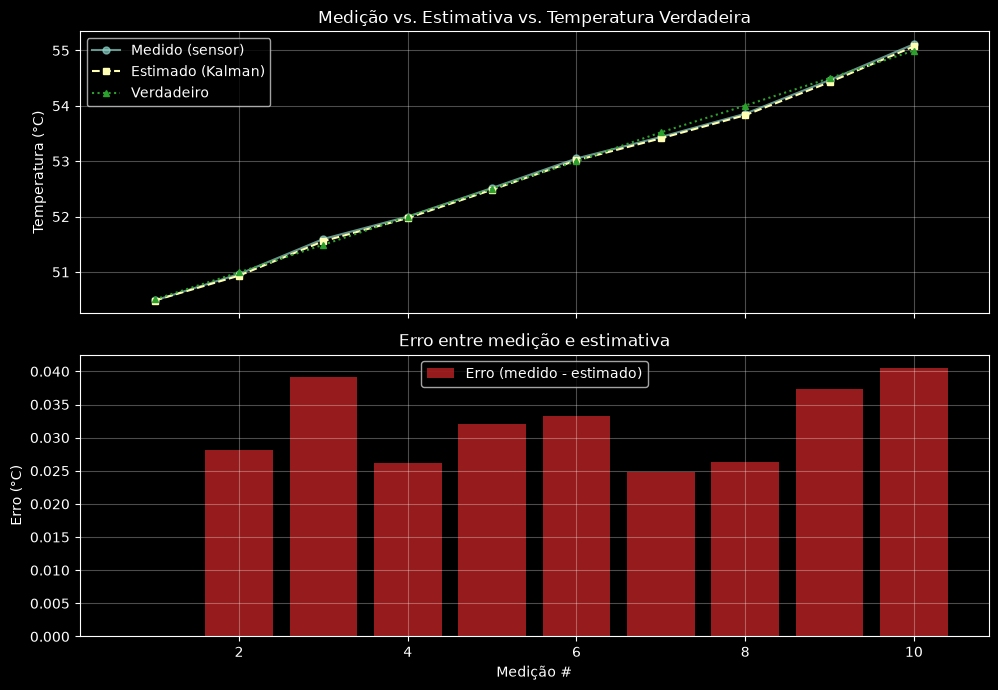

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- Medido vs Estimado vs Verdadeiro ---
axes[0].plot(n_passos, medicoes, "o-", label="Medido (sensor)", markersize=5, alpha=0.7)
axes[0].plot(n_passos, estimativas, "s--", label="Estimado (Kalman)", markersize=5)
axes[0].plot(
    n_passos, verdadeiras, "^:", label="Verdadeiro", color="tab:green", markersize=5
)
axes[0].set_ylabel("Temperatura (°C)")
axes[0].set_title("Medição vs. Estimativa vs. Temperatura Verdadeira")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Erro ---
axes[1].bar(
    n_passos,
    erros_vs_medido,
    color="tab:red",
    alpha=0.7,
    label="Erro (medido - estimado)",
)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_xlabel("Medição #")
axes[1].set_ylabel("Erro (°C)")
axes[1].set_title("Erro entre medição e estimativa")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

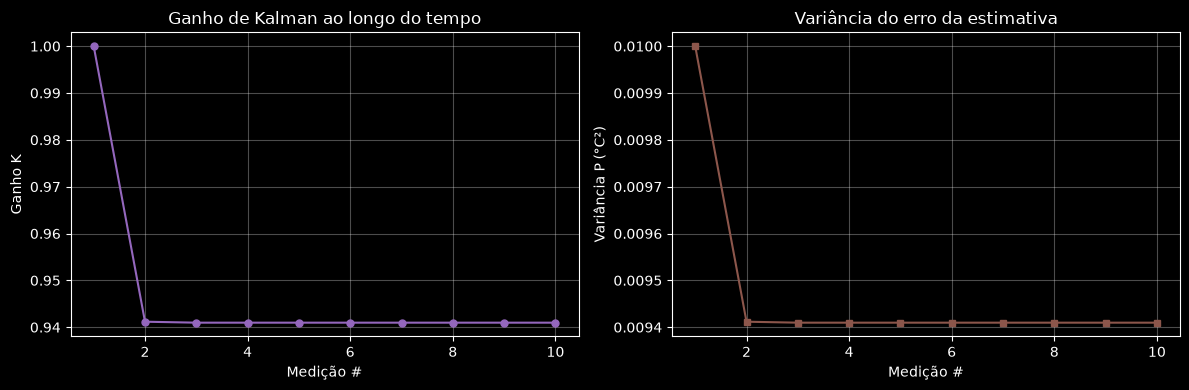

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Ganho de Kalman ---
axes[0].plot(n_passos, ganhos, "o-", color="tab:purple", markersize=5)
axes[0].set_xlabel("Medição #")
axes[0].set_ylabel("Ganho K")
axes[0].set_title("Ganho de Kalman ao longo do tempo")
axes[0].grid(True, alpha=0.3)

# --- Variância do erro ---
axes[1].plot(n_passos, variancias, "s-", color="tab:brown", markersize=5)
axes[1].set_xlabel("Medição #")
axes[1].set_ylabel("Variância P (°C²)")
axes[1].set_title("Variância do erro da estimativa")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()